Kristal Lee\
DSC 550\
18 Jul 2024\
Prof. Dr. Brett Werner
# Term Project

# Milestone 1

## Introduction/Business Problem

The business problem this project is looking to address revolves around crime in the city of Seattle. Seattle Police Department (SPD) provides their crime data dating back to 2008. The data used in the project is from the Seattle government website, [here.](https://data.seattle.gov/Public-Safety/SPD-Crime-Data-2008-Present/tazs-3rd5/about_data) The topic itself is of interest to me as my husband is an officer for Seattle. I often hear about the how crime in the city is going, and how they are well understaffed for the area they cover. I wanted to see for myself how the crime data breaks down and speaks. The specific item I am seeking to analyze and model is in which precinct a specific type of crime would occur and also based on the time of the year. The business problem this would potentially address is how to better staff areas or adjust patrolling styles for the different precincts. As crime has gone up in the area and Seattle Police Department is short-staffed, as many departments across the nation are, it may be helpful how to a data-driven plan for how to police certain areas during the year. This could also be helpful information overall as to how to prepare oneself if they're living or in the area on what types of crimes are more likely to happen.

## Approach/Data Cleaning

As the dataset is over one million rows long, I wanted to clean the data up to only look at the past ten years. I also looked to removing columns that were not going to be looked at for the purposes of this project. I mainly am focusing on the the report date, parent offense group, and precinct (and related) information. Since precinct was one of the main fields I was going to look at, I had to also address values that were not relevant. There were "Unknown" and "OOJ" values in the field, and they were also removed from the dataset. "OOJ" refers to "Outside of Jurisdiction", and thus would not be relvant to areas specific to the city of Seattle. 

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
import time
import datetime

In [181]:
# load data
location = '/Users/kristallee/Documents/Summer 2024/550/Term Project/SPD_crime_data.csv'
crime = pd.read_csv(location)

In [182]:
# create a subset from the data to only include columns using
crime_sub = crime.drop(['Report Number', 'Offense ID', 'Offense End DateTime','Group A B', 'Offense Code', 'MCPP', \
                        '100 Block Address', 'Longitude', 'Latitude'], axis=1)

In [183]:
# convert datetime fields to datetime format
crime_sub['Offense Start DateTime'] = pd.to_datetime(crime_sub['Offense Start DateTime'])
crime_sub['Report DateTime'] = pd.to_datetime(crime_sub['Report DateTime'])

In [184]:
# get the years and months for the crime reports
crime_sub['Report Year'] = crime_sub['Report DateTime'].apply(lambda x: x.year)
crime_sub['Report Month'] = crime_sub['Report DateTime'].apply(lambda x: x.month)

In [185]:
# filter to data for only last 10 full years as data set is very large
crime_sub = crime_sub.loc[(crime_sub['Report Year'] >= 2013) & (crime_sub['Report Year']< 2024)]
# len(crime_sub)

In [186]:
# convert all precincts to uppercase
crime_sub['Precinct'] = crime_sub['Precinct'].apply(lambda x: x.upper())

In [187]:
# precincts defined that I am interested  
# other values included INCLUDED and OOJ which stands for "Out of Jurisdiction"
precincts = ['W', 'N', 'SW', 'E','S']
prec = crime_sub['Precinct'].isin(precincts)
crime_sub = crime_sub[prec]
# len(crime_sub)

In [188]:
# get array of unique years and months
years = np.array(crime_sub['Report Year'].unique())
months = np.array(crime_sub['Report Month'].unique())

In [189]:
crime_sub.describe(include=['O'])

,Crime Against Category,Offense Parent Group,Offense,Precinct,Sector,Beat
count,780153,780153,780153,780153,780153,780153
unique,4,32,58,5,20,54
top,PROPERTY,LARCENY-THEFT,Theft From Motor Vehicle,N,U,K3
freq,586323,288159,120629,257465,65193,24629


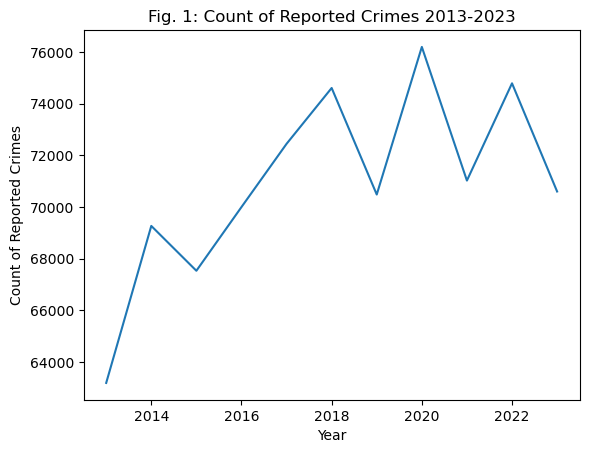

In [190]:
plt.plot(crime_sub.groupby('Report Year')['Report Year'].count())
plt.title('Fig. 1: Count of Reported Crimes 2013-2023')
plt.xlabel('Year')
plt.ylabel('Count of Reported Crimes')
plt.show()

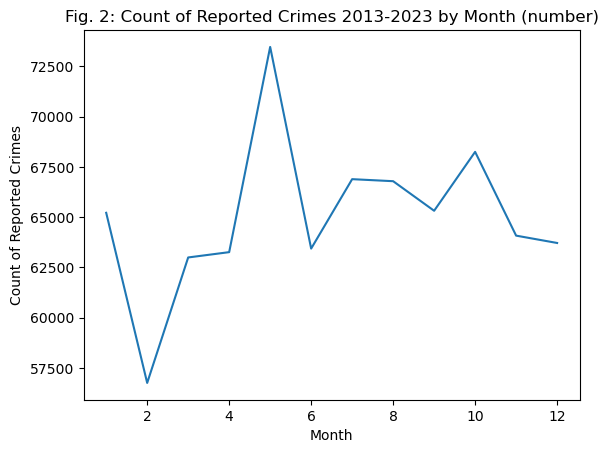

In [191]:
plt.plot(crime_sub.groupby('Report Month')['Report Month'].count())
plt.title('Fig. 2: Count of Reported Crimes 2013-2023 by Month (number)')
plt.xlabel('Month')
plt.ylabel('Count of Reported Crimes')
plt.show()

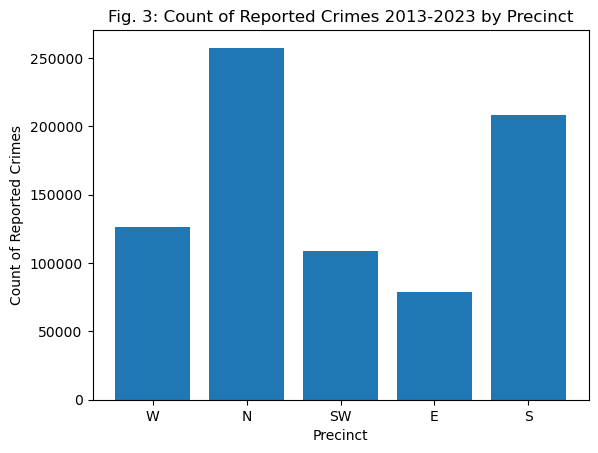

In [192]:
plt.bar(precincts,crime_sub.groupby('Precinct')['Precinct'].count())
plt.title('Fig. 3: Count of Reported Crimes 2013-2023 by Precinct')
plt.xlabel('Precinct')
plt.ylabel('Count of Reported Crimes')
plt.show()

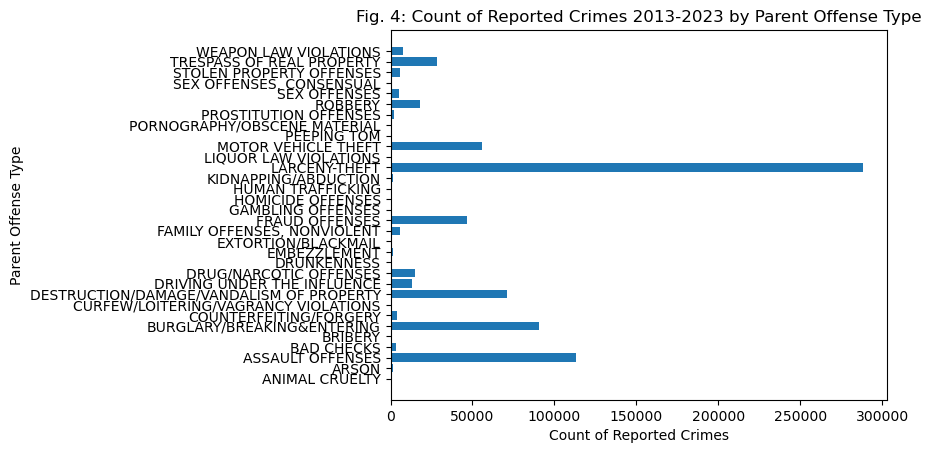

In [193]:
off_types = np.sort(np.array(crime_sub['Offense Parent Group'].unique()))
plt.barh(off_types,crime_sub.groupby('Offense Parent Group')['Offense Parent Group'].count())
plt.title('Fig. 4: Count of Reported Crimes 2013-2023 by Parent Offense Type')
plt.ylabel('Parent Offense Type')
plt.xlabel('Count of Reported Crimes')
plt.show()

In [194]:
# sort counts of crime by parent group
sorted = crime_sub.groupby('Offense Parent Group')['Offense Parent Group'].count().sort_values(ascending=False)
top5 = sorted[:5]
# get list of top five offense parent groups
top5_index = top5.index

In [195]:
# get counts of crime by filtered data by precinct
nfilter = crime_sub.loc[crime_sub['Precinct'] == 'N'].groupby('Offense Parent Group')['Offense Parent Group'].count()
wfilter = crime_sub.loc[crime_sub['Precinct'] == 'W'].groupby('Offense Parent Group')['Offense Parent Group'].count()
swfilter = crime_sub.loc[crime_sub['Precinct'] == 'SW'].groupby('Offense Parent Group')['Offense Parent Group'].count()
efilter = crime_sub.loc[crime_sub['Precinct'] == 'E'].groupby('Offense Parent Group')['Offense Parent Group'].count()
sfilter = crime_sub.loc[crime_sub['Precinct'] == 'S'].groupby('Offense Parent Group')['Offense Parent Group'].count()

# create new data frame with counts and the top five parent offenses
df = pd.DataFrame({'N': nfilter, 
                   'W': wfilter,
                   'SW': swfilter,
                   'E': efilter,
                   'S': sfilter}, index = top5_index)

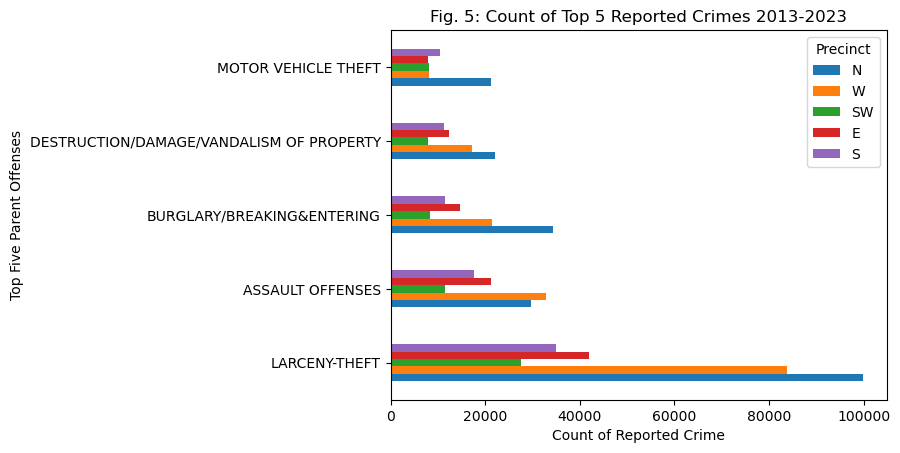

In [196]:
ax = df.plot.barh()
plt.title('Fig. 5: Count of Top 5 Reported Crimes 2013-2023')
plt.ylabel('Top Five Parent Offenses')
plt.xlabel('Count of Reported Crime')
plt.legend(title='Precinct')
plt.show()

## Overview/Conclusion

Figure 1 showed how crime overall did increase from ten years ago. However, there has been some fluctuation in the past couple of years. I was a bit surprised at first to see that 2020 had a higher crime count despite the COVID pandemic. However, there was a lot of raiding and looting going on during this time, as well as the nationally watched Capitol Hill Occupied Protests (CHOP) went on. Figure 2 shows crime counts were highest in May. Figure 3 shows which precinct has the most reported crimes. I was not particularly surprised because the North precinct spans the largest area. In Figure 4, I was also surprised to see by how much larceny theft dominated the offense group. I did not expect it to be about 250% more than the next highest. Lastly, in Figure 5, I broke down the top five crimes by count for the different precincts. It was interesting to see where the North precinct was not the top contributor, such as in assault, where it was beat out by the West precinct.

# Milestone 2

In [197]:
# crime.columns

## Step 1
Create a smaller data set dropping by dropping irrelevant columns. Report number and offense ID are not relevant because they are not dependent featues as they're only identifiers for each row like a name. Report date and offense end date are not being used as I am going off when the offense started rather than ended and not off of the report date because that is not relevant to the actual offense and could have occurred any time after the actual offense. 

In [198]:
crime2 = crime.drop(['Report Number', 'Offense ID', 'Report DateTime', 'Offense End DateTime'], axis=1)

## Step 2 
Dropping columns that are in part a subset of or are covered more generally in another column. Sector, beat, address, MCPP, longitude, and latitude are further descriptors or details that can are encompassed in Precinct. Offense code and offense stem from the Offense Parent Group.

In [199]:
crime2 = crime2.drop(['Sector', 'Beat', '100 Block Address', 'Longitude', \
                      'Latitude', 'Offense Code', 'MCPP', 'Offense'], axis=1)

In [200]:
# convert Offense Start to datetime format
crime2['Offense Start DateTime'] = pd.to_datetime(crime2['Offense Start DateTime'])

In [201]:
# get the years and months for the offense start
crime2['Offense Year'] = crime2['Offense Start DateTime'].apply(lambda x: x.year)
crime2['Offense Month'] = crime2['Offense Start DateTime'].apply(lambda x: x.month)

## Step 3
Use only data reported for the past full ten years. This is to bring down the number of rows of data as the original is over one million pieces long.

In [202]:
crime2 = crime2.loc[(crime2['Offense Year'] >= 2013) & (crime2['Offense Year']< 2024)]

In [203]:
# check for any empty cells
crime2.isna().sum()

Offense Start DateTime    0
Group A B                 0
Crime Against Category    0
Offense Parent Group      0
Precinct                  0
Offense Year              0
Offense Month             0
dtype: int64

## Step 4
Using the time parameter of the offense start datetime, classify whether the offense happened in the day or night, where day time being from 6am - 6pm, and night being 6pm to 6am.

In [204]:
# create function to classify offense time
def daynight(x):
    # if the hour is before 6am or after 6pm, return night
    if x.time().hour < 6 or x.time().hour >= 18:
        return 'Night'
    # if the hour is between 6am and 6pm, return day
    elif x.time().hour >= 6 and x.time().hour < 18:
        return 'Day'

In [205]:
# apply day night function and add a new column for day/night classification
crime2['DayNight'] = crime2['Offense Start DateTime'].apply(daynight)

## Step 5
Remove rows where the recincts are either unknown or OOJ meaning "out of juristiction". 

In [206]:
# uppercase all of the precincts for comparison
crime2['Precinct'] = crime2['Precinct'].apply(lambda x: x.upper())

In [207]:
# only keep precincts that are within the previously defined precinct list which excludes unknown and OOJ. 
crime2 = crime2.loc[crime2['Precinct'].isin(precincts)]

## Step 6
Grab an even smaller subset of the data that will be used for building a model

In [208]:
crime2_sub = crime2.drop(['Offense Start DateTime', 'Offense Year'], axis=1)
crime2_sub.head()

,Group A B,Crime Against Category,Offense Parent Group,Precinct,Offense Month,DayNight
0,A,SOCIETY,DRUG/NARCOTIC OFFENSES,W,2.0,Day
1,A,PROPERTY,LARCENY-THEFT,N,2.0,Day
2,A,PROPERTY,ROBBERY,N,2.0,Night
3,A,PROPERTY,DESTRUCTION/DAMAGE/VANDALISM OF PROPERTY,W,2.0,Night
4,B,SOCIETY,DRIVING UNDER THE INFLUENCE,N,2.0,Night


## Step 7 
Remap what will be later be the target variable to numerical values for each precinct. 

In [209]:
replacements = {'N':1, 'E':2, 'S':3, 'SW':4, 'W':5}
crime2_sub['Precinct'] = crime2_sub['Precinct'].map(replacements)

## Step 8
Create dummy variables for all categorical variables which are Groups A B, Crimes Against Category, Offense Parent Group, and DayNight

In [210]:
dummies = pd.get_dummies(data = crime2_sub, columns=['Group A B','Crime Against Category', \
                                                     'Offense Parent Group', 'DayNight'])

In [211]:
# show the shape of dummy dataset and columns
print(dummies.shape)
# dummies.columns

(778330, 42)


# Milestone 3

In [212]:
target = dummies['Precinct']
features = dummies.drop('Precinct', axis=1)

In [213]:
from sklearn.model_selection import train_test_split

## KNN with all features

In [214]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn.pipeline import Pipeline, FeatureUnion

In [215]:
# split data into training and test sets 80/20 with all features
features_train, features_test, target_train, target_test = train_test_split(features, \
                                                                            target, test_size=0.2, random_state=0)

In [216]:
# set the min max scaler 
minmax_scale = preprocessing.MinMaxScaler(feature_range=(0,1))
# knn classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
# pipeline
knnpipe = Pipeline([('min-max', minmax_scale), ('knn', knn)])

In [217]:
# fit model
knnpipe.fit(features_train, target_train)

Pipeline(steps=[('min-max', MinMaxScaler()),
                ('knn', KNeighborsClassifier(n_jobs=-1))])

In [218]:
# knn predicitons 
pred_knn_full = knnpipe.predict(features_test)

In [219]:
from sklearn.metrics import accuracy_score

In [247]:
# find the accuracy of the default model
acc_knn_full = accuracy_score(target_test, pred_knn_full)
# print("Accuracy - KNN model with all features: {0:.3f} ".format(acc_knn_full))

## KNN w/ Best 10 feature selection

In [221]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif

In [222]:
# select 10 best features 
chi2_selector = SelectKBest(chi2, k=10)
features_kbest = chi2_selector.fit_transform(features, target)

In [223]:
mask = chi2_selector.get_support()
new_features = features.columns[mask]
feature_list = list(new_features)
# print("Ten selected features:",feature_list)

In [224]:
# features for only 10 selected 
features_top10 = features[feature_list]

In [225]:
# split training and test set from subset of 10 features from original features 
features_train_top10, features_test_top10, target_train_top10, target_test_top10 = train_test_split(features_top10, \
                                                                            target, test_size=0.2, random_state=0)

In [226]:
# fit the model with default KNN (n = 5)
knn_pipe_top10 = knnpipe.fit(features_train_top10, target_train_top10)

In [227]:
# get the predicitions
pred_knn_top10 = knn_pipe_top10.predict(features_test_top10)

In [248]:
acc_knn_top10 = accuracy_score(target_test_top10, pred_knn_top10)
# print("Accuracy - KNN model with top 10 features: {0:.3f} ".format(acc_knn_top10))

## Logistic Regression

In [229]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [230]:
scaler = StandardScaler()

In [231]:
features_standardized = scaler.fit_transform(features)

In [232]:
logistic_regression = LogisticRegression(random_state=0, multi_class="ovr")

In [233]:
# retrain data with standardization scaler
features_train_std, features_test_std, target_train_std, target_test_std = train_test_split(features_standardized, \
                                                                            target, test_size=0.2, random_state=0)

In [234]:
log_model = logistic_regression.fit(features_train_std, target_train_std)

In [235]:
pred_log = log_model.predict(features_test_std)

In [249]:
# Accuracy for logistic regression 
acc_log = accuracy_score(target_test_std, pred_log)
# print("Accuracy - Logistic Regression: {0:.3f} ".format(acc_log))

## Decision Tree: Full Features

In [237]:
from sklearn.tree import DecisionTreeClassifier

In [238]:
decisiontree = DecisionTreeClassifier(random_state=0)

In [239]:
# model using all features 
dt_model_full = decisiontree.fit(features_train, target_train)

In [240]:
pred_dt_full = dt_model_full.predict(features_test)

In [250]:
# find the accuracy for all features
acc_dt_full = accuracy_score(target_test, pred_dt_full)
# print("Accuracy - Decision Tree with all features: {0:.3f} ".format(acc_dt_full))

## Decision Tree: Top 10 Features

In [242]:
dt_model_top10 = decisiontree.fit(features_train_top10, target_train_top10)

In [243]:
# model using top 10 features 
pred_dt_top10 = dt_model_top10.predict(features_test_top10)

In [251]:
# find the accuracy of the default model
acc_dt_top10 = accuracy_score(target_test_top10, pred_dt_top10)
# print("Accuracy - Decision Tree with top 10 features: {0:.3f} ".format(acc_dt_top10))

## Model Accuracies

In [246]:
print("Model Accuracies:")
print("KNN - full : {0:.3f} ".format(acc_knn_full))
print("KNN - top 10 : {0:.3f} ".format(acc_knn_top10))
print("Log. Regression: {0:.3f} ".format(acc_log))
print("Decision Tree - full : {0:.3f} ".format(acc_dt_full))
print("Decision Tree - top 10 : {0:.3f} ".format(acc_dt_top10))

Model Accuracies:
KNN - full : 0.289 
KNN - top 10 : 0.310 
Log. Regression: 0.340 
Decision Tree - full : 0.341 
Decision Tree - top 10 : 0.338 


## Summary

The purpose of a model for this data is to predict which precinct a crime will occur based on the narrowed fields from the original data set from the past ten years crime data in Seattle. As there are five precincts, the prediction value is categorical. The models that were selected to test were K-nearest neighbors, logistic regression, and decision trees as they are classification-type models. Five iterations of the various models were ran, where for the KNN and decision tree models, an additional model was ran for a even more narrowed feature selection. The top ten features were selected and used rather than all. Of all the models ran, the model with the highest accuracy was the decision tree with the full set of features closely followed by the logistic regression model. 

Overall, the model is not particuarly great as the accuracy ranges from ~29% to just over 34%. At best, it would, theorethically, accurately predict one third of where a crime would occur. 